### [Leveraging Momentum: Build An Active Trading Strategy](https://python.plainenglish.io/leveraging-momentum-build-your-active-trading-strategy-fdfd65d266a6)

> Quantitative Finance Series: Building and Backtesting a Momentum Trading Strategy

In [1]:
!pip install -q numpy pandas matplotlib yfinance

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Define our universe of stocks (a selection from the S&P 100 for diversity)
tickers = [
    'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'NVDA', 'JPM', 'JNJ', 'V', 'PG', 'UNH',
    'HD', 'MA', 'BAC', 'DIS', 'PFE', 'ADBE', 'CRM', 'NFLX', 'KO', 'PEP',
    'XOM', 'CVX', 'LLY', 'AVGO', 'COST', 'MCD', 'WMT', 'CSCO', 'ACN', 'TMO'
]

# Define the backtest period
start_date = '2013-01-01'
end_date = '2023-12-31'

# Fetch monthly closing prices. We use monthly data for this strategy.
monthly_prices = yf.download(tickers, start=start_date, end=end_date, interval='1mo')['Close']
monthly_prices = monthly_prices.dropna(axis=1) # Drop stocks with missing data

# Calculate monthly returns
monthly_returns = monthly_prices.pct_change().dropna()

print("Shape of monthly returns data:", monthly_returns.shape)
monthly_returns.head()

/tmp/ipython-input-2848558713.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  monthly_prices = yf.download(tickers, start=start_date, end=end_date, interval='1mo')['Close']
[*********************100%***********************]  30 of 30 completed

Shape of monthly returns data: (131, 30)


Ticker,AAPL,ACN,ADBE,AMZN,AVGO,BAC,COST,CRM,CSCO,CVX,...,NFLX,NVDA,PEP,PFE,PG,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,-0.030934,0.034358,0.039122,-0.004633,-0.043332,-0.007950,-0.010260,-0.016906,0.014098,0.017368,...,0.138223,0.032627,0.040083,0.012068,0.021789,0.023011,-0.031878,0.004623,0.011866,-0.004668
2013-03-01,0.008699,0.021652,0.107097,0.008401,0.049678,0.085570,0.050382,0.056790,0.001917,0.022152,...,0.006380,0.019646,0.051548,0.054439,0.011551,0.036450,0.070346,0.072858,0.057220,0.012682
2013-04-01,0.000271,0.072002,0.035846,-0.047582,-0.105515,0.010673,0.021864,-0.080467,0.000957,0.026847,...,0.141536,0.073265,0.042472,0.007276,-0.003764,0.056819,0.051610,-0.008125,0.045322,-0.012430
2013-05-01,0.015696,0.019058,-0.048137,0.060636,0.180539,0.109667,0.011067,0.029677,0.162284,0.006065,...,0.047114,0.050835,-0.020614,-0.063295,0.007216,0.094447,0.045052,0.057462,-0.037056,0.016631
2013-06-01,-0.112457,-0.123615,0.061757,0.031538,-0.009277,-0.058566,0.011389,-0.098039,0.009121,-0.028152,...,-0.067006,-0.024788,0.012629,0.037220,0.002997,-0.041563,0.045506,0.027759,0.001293,0.005582


In [3]:
# Strategy Parameters
lookback_period = 12
skip_months = 1 # Skip the most recent month
top_n_pct = 0.20 # We'll go long the top 20% of stocks

# Store portfolio returns
portfolio_returns = []
# Store dates for the returns series
portfolio_dates = []

# The main backtest loop starts after our initial lookback period
for i in range(lookback_period, len(monthly_returns)):

    # 1. Define the momentum calculation window
    # We look from i-12 months to i-1 months ago
    momentum_window = monthly_returns.iloc[i - lookback_period : i - skip_months]

    # 2. Calculate cumulative returns over the window (our momentum score)
    momentum_score = (1 + momentum_window).prod() - 1

    # 3. Rank the stocks
    momentum_score = momentum_score.sort_values(ascending=False)

    # 4. Form the portfolio for the NEXT month
    num_stocks = len(momentum_score)
    top_n = int(num_stocks * top_n_pct)

    # Select the top N stocks (our "winners")
    long_portfolio = momentum_score.head(top_n)
    winner_tickers = long_portfolio.index

    # 5. Calculate the portfolio's return for the holding period (month i)
    # This is the crucial "walk-forward" step. We use the returns from the month
    # immediately following our calculation period.
    holding_month_returns = monthly_returns.iloc[i][winner_tickers]

    # Assume an equal-weighted portfolio of the winners
    period_return = holding_month_returns.mean()

    # 6. Store the results
    portfolio_returns.append(period_return)
    portfolio_dates.append(monthly_returns.index[i])

# Create a pandas Series from the results
momentum_strategy_returns = pd.Series(portfolio_returns, index=portfolio_dates)
momentum_strategy_returns.name = "Momentum Strategy"

print("\nMomentum Strategy Monthly Returns (first 5 months):")
momentum_strategy_returns.head()


Momentum Strategy Monthly Returns (first 5 months):


,Momentum Strategy
2014-02-01,0.082808
2014-03-01,-0.047570
2014-04-01,-0.036221
2014-05-01,0.083510
2014-06-01,0.036413


In [4]:
# Download SPY data for the same period
spy_data = yf.download('SPY', start=start_date, end=end_date, interval='1mo')['Close']
spy_returns = spy_data.pct_change().dropna()
spy_returns.name = "S&P 500 Benchmark"

# Align the benchmark returns with our strategy's dates
spy_returns = spy_returns.loc[momentum_strategy_returns.index]
spy_returns.head()

/tmp/ipython-input-3262635905.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download('SPY', start=start_date, end=end_date, interval='1mo')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,SPY
2014-02-01,0.045516
2014-03-01,0.003865
2014-04-01,0.011396
2014-05-01,0.023206
2014-06-01,0.015778


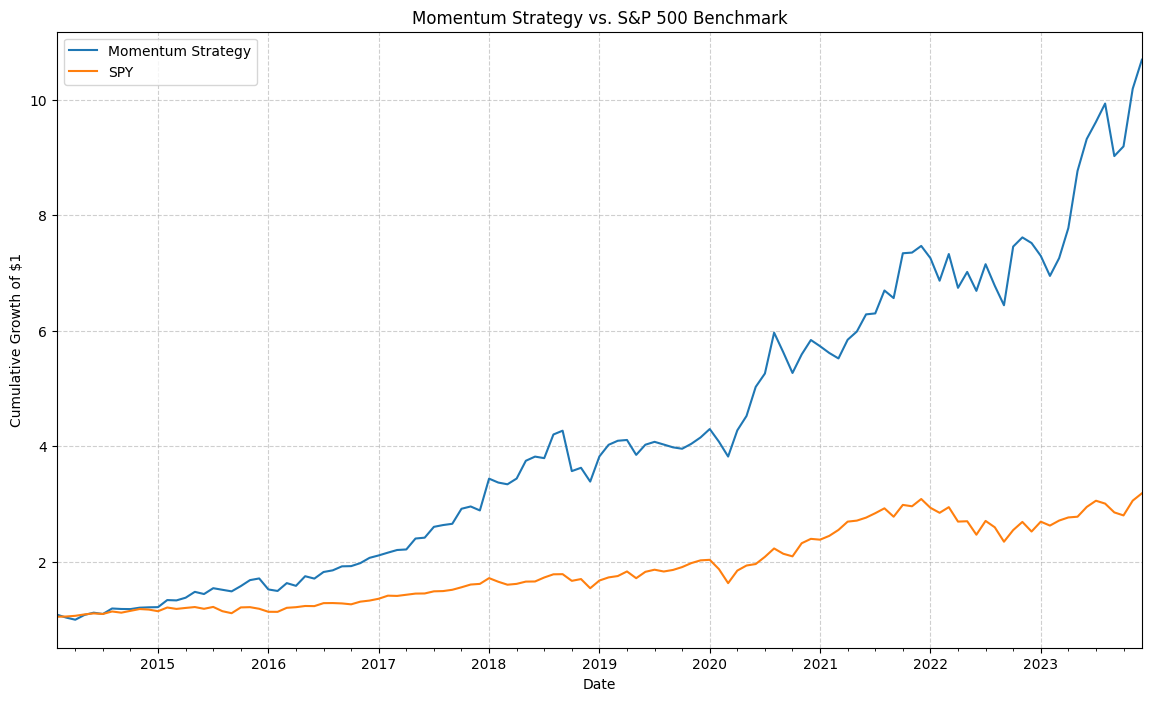


--- Backtest Performance Metrics ---


,Momentum Strategy,S&P 500 Benchmark
Cumulative Return,969.40%,218.32%
Annualized Return (CAGR),26.99%,12.39%
Annualized Volatility,20.02%,15.49%
Sharpe Ratio,1.25,0.67
Maximum Drawdown,-20.66%,-23.97%


In [5]:
# Calculate cumulative returns
cumulative_momentum = (1 + momentum_strategy_returns).cumprod()
cumulative_spy = (1 + spy_returns).cumprod()

# Plot the equity curves
plt.figure(figsize=(14, 8))
cumulative_momentum.plot(label=momentum_strategy_returns.name, legend=True)
# Extract the 'SPY' column as a Series to access its name
cumulative_spy['SPY'].plot(label=spy_returns['SPY'].name, legend=True)
plt.title('Momentum Strategy vs. S&P 500 Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Performance Metrics Calculation ---
def calculate_performance_metrics(returns):
    total_return = (1 + returns).prod() - 1
    num_years = len(returns) / 12
    annualized_return = (1 + total_return) ** (1/num_years) - 1
    annualized_volatility = returns.std() * np.sqrt(12)
    sharpe_ratio = (annualized_return - 0.02) / annualized_volatility # Assuming 2% risk-free rate

    cumulative_returns = (1 + returns).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns/peak) - 1
    max_drawdown = drawdown.min()

    metrics = {
        'Cumulative Return': f"{total_return:.2%}",
        'Annualized Return (CAGR)': f"{annualized_return:.2%}",
        'Annualized Volatility': f"{annualized_volatility:.2%}",
        'Sharpe Ratio': f"{sharpe_ratio:.2f}",
        'Maximum Drawdown': f"{max_drawdown:.2%}"
    }
    return pd.Series(metrics)

# Calculate metrics for the momentum strategy
momentum_metrics = calculate_performance_metrics(momentum_strategy_returns)

# Calculate metrics for the benchmark (using the 'SPY' column as a Series)
benchmark_metrics = calculate_performance_metrics(spy_returns['SPY'])

results_df = pd.DataFrame({
    'Momentum Strategy': momentum_metrics,
    'S&P 500 Benchmark': benchmark_metrics
})

print("\n--- Backtest Performance Metrics ---")
display(results_df)